In [10]:
import sys
import os
sys.path.append("../src")

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from dataset import CustomSegmentationDataset, TestDataset
from model import get_deeplabv3plus
from infer import inference
from utils import JsonUtils

## モデルの呼び出し

In [4]:
num_classes = 2  # クラス数に応じて変更
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_deeplabv3plus(num_classes).to(device)

# annotationラベルの指定
label_map = {
    "background": 0,
    "vacant_lot": 1,
}

# モデルの読み込み
model_path = "../models/model_v2.pth"
model.load_state_dict(torch.load(model_path))

# 学習履歴の読み込み
history_path = "../models/history_v2.pth"
history = torch.load(history_path)

d:\python_workspace\detect-emptylots\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\python_workspace\detect-emptylots\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## ファイルパスの指定

In [5]:
# ファイルの入出力先の指定
test_img_file = "../data/test/images" # テスト画像の入力元
test_ann_file = "../data/test/annotations/predictions_v3.json" # テストの推論結果の出力先

In [7]:
# テストデータセットの作成
test_dataset = TestDataset(test_img_file, transform=None, target_size=(256, 256))

# 推論結果を保存するリスト
pred_masks = []
file_names = []
widths = []
heights = []

# 各画像に対して推論を実行
for idx in range(len(test_dataset)):
    # 画像とファイル名を取得
    image, file_name = test_dataset[idx]
    
    # 元の画像サイズを取得
    with Image.open(os.path.join(test_img_file, file_name)) as img:
        width, height = img.size
    
    # 推論を実行
    pred_mask = inference(model, image, original_size=(height, width), device=device)
    
    # 結果を保存
    pred_masks.append(pred_mask)
    file_names.append(file_name)
    widths.append(width)
    heights.append(height)
    
    # 進捗表示
    if (idx + 1) % 10 == 0:
        print(f"Processed {idx + 1}/{len(test_dataset)} images")

# 推論結果をJSONファイルに保存
JsonUtils.mask_to_json(
    masks=pred_masks,
    file_names=file_names,
    output_path=test_ann_file,
    widths=widths,
    heights=heights
)

d:\python_workspace\detect-emptylots\.venv\Lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
d:\python_workspace\detect-emptylots\notebooks\../src\infer.py:34: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(


Processed 10/2500 images
Processed 20/2500 images
Processed 30/2500 images
Processed 40/2500 images
Processed 50/2500 images
Processed 60/2500 images
Processed 70/2500 images
Processed 80/2500 images
Processed 90/2500 images
Processed 100/2500 images
Processed 110/2500 images
Processed 120/2500 images
Processed 130/2500 images
Processed 140/2500 images
Processed 150/2500 images
Processed 160/2500 images
Processed 170/2500 images
Processed 180/2500 images
Processed 190/2500 images
Processed 200/2500 images
Processed 210/2500 images
Processed 220/2500 images
Processed 230/2500 images
Processed 240/2500 images
Processed 250/2500 images
Processed 260/2500 images
Processed 270/2500 images
Processed 280/2500 images
Processed 290/2500 images
Processed 300/2500 images
Processed 310/2500 images
Processed 320/2500 images
Processed 330/2500 images
Processed 340/2500 images
Processed 350/2500 images
Processed 360/2500 images
Processed 370/2500 images
Processed 380/2500 images
Processed 390/2500 im

## 推論結果の可視化

In [ ]:
# ファイルの入出力先の指定
test_img_file = "../data/test/images" # テスト画像の入力元
test_ann_file = "../data/test/annotations/predictions_v3.json" # テストの推論結果の出力先

# データセットの読み込み
test_dataset = CustomSegmentationDataset(test_img_file, test_ann_file, label_map, transform=None, target_size=(256, 256))

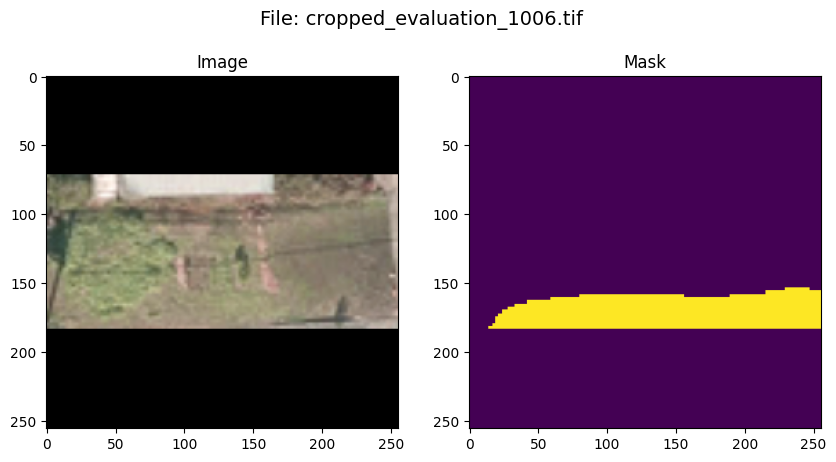

In [19]:
# サンプル画像とマスクの可視化
idx = 10

img, mask = test_dataset[idx]
file_name = test_dataset.annotations_data[idx]['file_name']

plt.figure(figsize=(10,5))
plt.suptitle(f"File: {file_name}", fontsize=14) 
plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(img.permute(1, 2, 0))
plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(mask)
plt.show()